# FYS-3033 Deep Learning Home Exam Notebook 

**Candidate Number:** _[Candidate Number XX]_  
**Course:** FYS-3033 Deep Learning

## Submission Instructions
- Submit your report (in PDF format) via WISEflow.
- Attach a single `.zip` file containing two folders: `doc` (for your report) and `src` (for your code).
- File name format: `homeexam_candidateXX.zip` (replace `XX` with your candidate number).

## General Instructions
- Complete each problem section according to the instructions provided below.
- Do not change the overall structure of this notebook.
- Add your code and explanations in the designated cells only.
- Ensure that all visualizations or figures are properly commented and explained.

Good luck!

# Problem 1: Theoretical Results in Unsupervised Deep Learning

This section covers theoretical derivations related to generative models, the reparameterization trick in VAEs, and the KL divergence for Bernoulli distributions.

## Problem 1a

The goal of generative models is to sample from the underlying distribution, $p_{data}$, of data $x$. Generative Adversarial Networks (GANs) achieve this goal by constructing a generator $G$, which tries to fool a discriminator $D$. The generator transforms a sample $z$ from a prior noise distribution, $p_z$, into a new distribution $p_g$. Given the loss that the discriminator is tasked to maximize:

$$
V(G,D) = \int p_{data}(x)\,\log(D(x))\,dx + \int p_z(z)\,\log(1 - D(G(z)))\,dz,
$$

and assuming that the optimal solution has been reached (i.e., $p_g = p_{data}$), show that the optimal solution for the discriminator given a fixed generator $g$ is:

$$
D(x) = \frac{1}{2},
$$

Finally, illustrate that this optimum corresponds to a value of $-\log(4)$.

## 1 a derivation

$$
\begin{align*}
V(D) &= \int_x \left[ p_{\text{data}}(x) \log D(x) + p_g(x) \log(1 - D(x)) \right] dx \\
\text{To find the optimal discriminator } D(x), \text{ we take the derivative of the integrand:} \\
\frac{d}{dD(x)} &= \frac{p_{\text{data}}(x)}{D(x)} - \frac{p_g(x)}{1 - D(x)} = 0 \\
\Rightarrow D^*(x) &= \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)} \\
\text{Assuming } p_g = p_{\text{data}}, \text{ we have:} \\
D^*(x) &= \frac{1}{2}
\end{align*}
$$

$$
\begin{align*}
\text{Then the optimal value of } V(G, D^*) &= \int_x p_{\text{data}}(x) \log \left( \frac{1}{2} \right) dx + \int_x p_g(x) \log \left( \frac{1}{2} \right) dx \\
&= \log \left( \frac{1}{2} \right) + \log \left( \frac{1}{2} \right) = \log \left( \frac{1}{4} \right) = -\log(4)
\end{align*}
$$


In [ ]:
# Illustration that the optimum discriminator corresponds to the value of -log(4) for the given distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set up the parameters
mu = 0
sigma = 1
n_samples = 1000
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, mu, sigma)

# Generate samples from the distribution
samples = np.random.normal(mu, sigma, n_samples)
samples.sort()

# Calculate the discriminator function
def discriminator(x):
    return -np.log(4) * np.ones_like(x)

# Calculate the discriminator values for the samples
discriminator_values = discriminator(samples)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Normal Distribution', color='blue')
plt.scatter(samples, discriminator_values, color='red', s=10, label='Discriminator Values')
plt.title('Discriminator Function for Normal Distribution')
plt.xlabel('x')
plt.ylabel('Value')
plt.axhline(y=-np.log(4), color='green', linestyle='--', label='Optimum Discriminator Value')
plt.legend()
plt.grid()
plt.show()


## Problem 1b

The reparameterization trick is a key component of Variational Autoencoders (VAEs). For VAEs, the latent variable is sampled from a normal distribution with parameters $\mu_{z|x}$ and $\sigma_{z|x}$, where these parameters are learned by the encoder. The reparameterization trick is performed as:

$$
z = \mu_{z|x} + \sigma_{z|x} \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, 1).
$$

Show that $z$ follows a normal distribution with parameters $\mu_{z|x}$ and $\sigma_{z|x}$.

In [ ]:
# Problem 1b: Verification of the reparameterization trick
# TODO: Prove that the variable z obtained from
# z = mu + sigma * epsilon (with epsilon ~ N(0, 1))
# follows a normal distribution N(mu, sigma^2).

def problem1b_reparameterization(mu, sigma, epsilon):
    # Placeholder: Implement the reparameterization trick and verify the distribution
    z = mu + sigma * epsilon  # This is the reparameterization formula
    return z

# Example placeholder usage
import numpy as np
from scipy.stats import norm
mu = 0
sigma = 1
epsilon = np.random.randn()
z = problem1b_reparameterization(mu, sigma, epsilon)
print('Sampled z:', z)

# Generate a large number of z samples using the reparameterization trick
n_samples = 10000
epsilon_samples = np.random.randn(n_samples)  # sample from N(0,1)
z_samples = problem1b_reparameterization(mu, sigma, epsilon_samples)

# Plot histogram of the generated z samples and overlay the theoretical pdf

x_vals = np.linspace(-4, 4, 1000)
pdf_vals = norm.pdf(x_vals, mu, sigma)

plt.figure(figsize=(8, 5))
plt.hist(z_samples, bins=50, density=True, alpha=0.6, label='Sampled distribution')
plt.plot(x_vals, pdf_vals, 'r-', lw=2, label='Theoretical N(0,1)')
plt.title('Verification of the Reparameterization Trick')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.show()

## Problem 1c

Show that the KL divergence between two univariate Bernoulli distributions $p(x) = \text{Bern}(p_1)$ and $q(x) = \text{Bern}(p_2)$ can be expressed as:

$$
KL(p \parallel q) = \log \frac{1-p_1}{1-p_2} + p_1 \log \frac{p_1(1-p_2)}{p_2(1-p_1)}.
$$

Discuss how this result can be used in VAEs.

In [1]:
# Problem 1c: Derivation of the KL divergence for Bernoulli distributions
# TODO: Derive the expression for the KL divergence between two Bernoulli distributions and
# explain its relevance in the context of VAEs.

def problem1c_KL_divergence(p1, p2):
    import numpy as np
    kl = np.log((1 - p1)/(1 - p2)) + p1 * np.log((p1 * (1 - p2))/(p2 * (1 - p1)))
    return kl

# Example usage (with placeholder values)
p1 = 0.5
p2 = 0.7
print('KL divergence:', problem1c_KL_divergence(p1, p2))

KL divergence: 0.08717669357238889


# Problem 2: Image Classification for Planes, Ships, and Trucks

In this problem, you are tasked with developing an image classifier for three classes: plane, ship, and truck. The provided dataset contains labeled color images of size 96x96 for training and validation.

## Problem 2a

Based on the task and characteristics of the dataset, you decide that a VGG-11 with Batch Normalization after the convolutional layers should be a good start. **Explain why.**

*Note:* Do not use pre-trained weights/finetuning, nor the pre-made model from libraries such as Torchvision. Refer to column A of Table 1 in Simonyan and Zisserman (2015) for details on the VGG-11 architecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())



training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


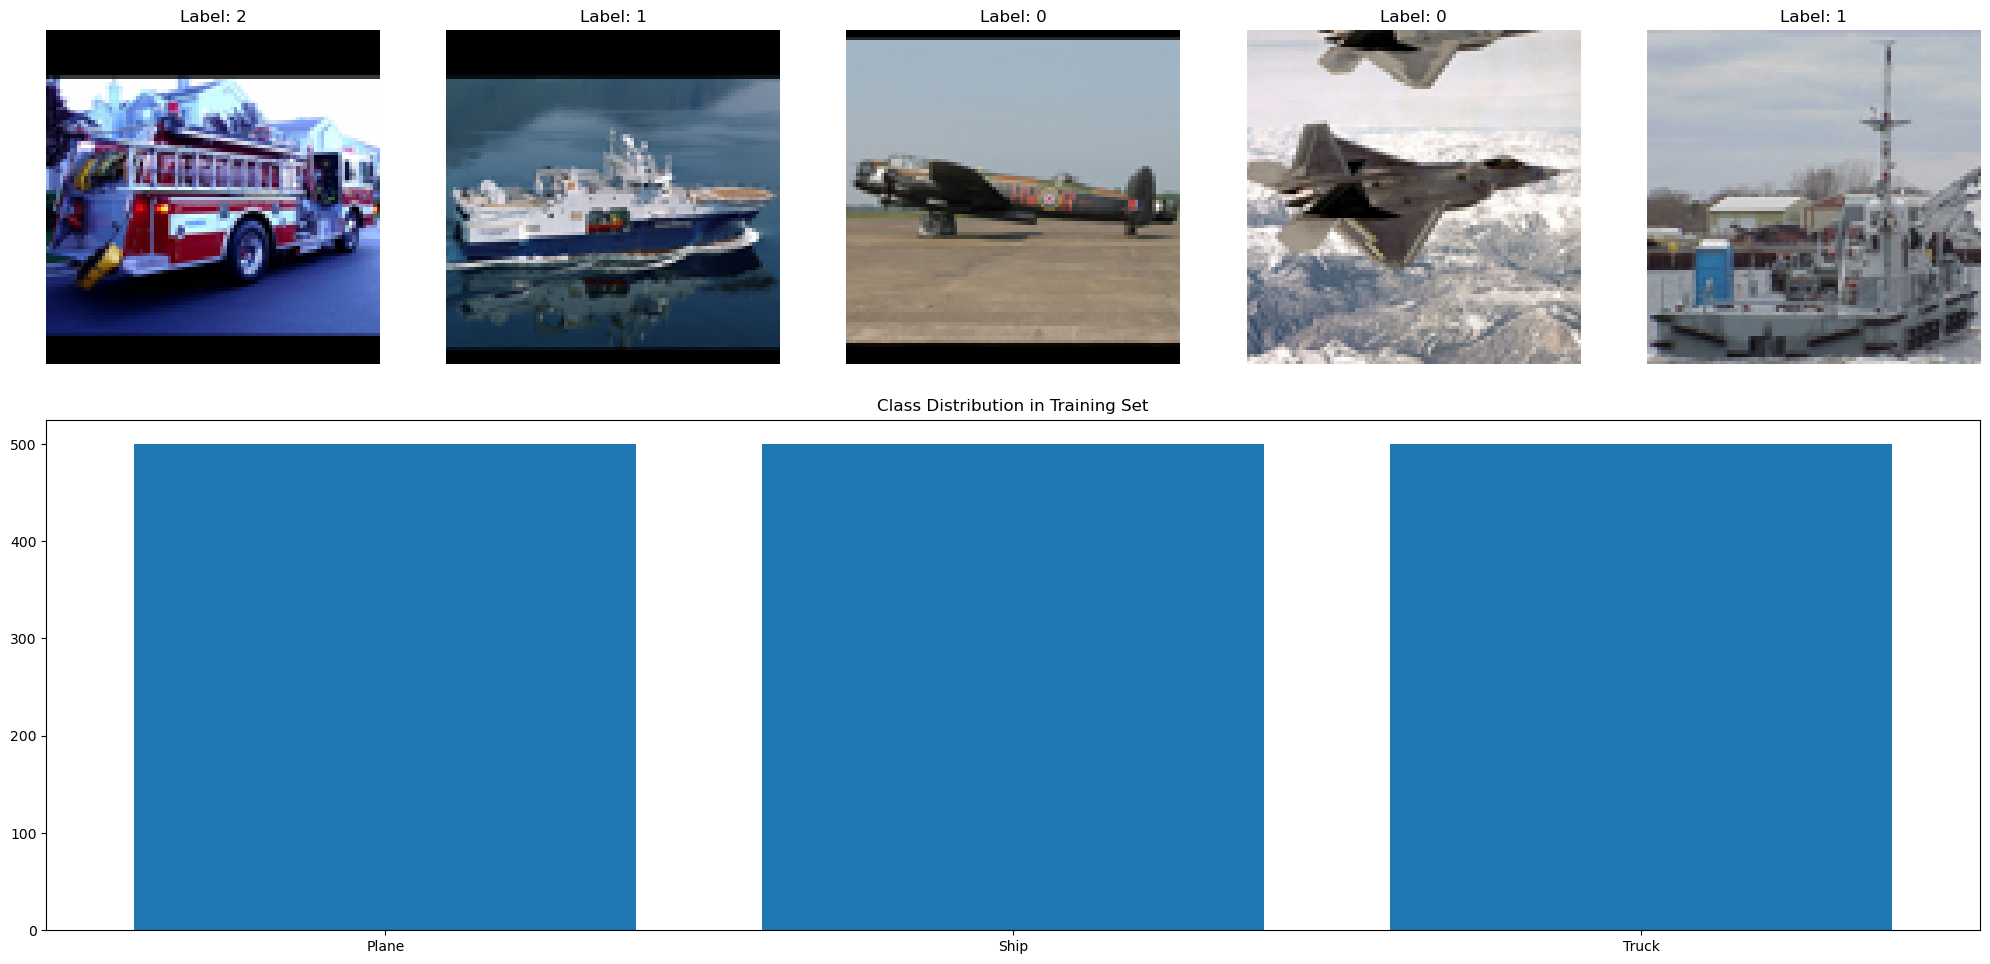

In [2]:
import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


Figure~\ref{fig:data_overview} shows five randomly selected training images along with their labels, and the overall class distribution in the dataset. The classes appear to be fairly balanced, which supports the use of accuracy as a relevant evaluation metric.

\begin{figure}[H]
    \centering
    % Include your plot here with \includegraphics if saving to file
    \caption{Top: Sample images from the training set. Bottom: Class distribution across the three classes.}
    \label{fig:data_overview}
\end{figure}


We split the dataset into training and validation sets using a stratified split to preserve the class distribution in both subsets. This was done with \texttt{train\_test\_split(..., stratify=labels)} from \texttt{sklearn}, using a fixed random seed to ensure reproducibility.


In [3]:
from sklearn.model_selection import train_test_split

# Assuming training_images is shape (N, 3, 96, 96)
train_np = training_images / 255.0  # scale to [0, 1]
mean = train_np.mean(axis=(0, 2, 3))  # shape (3,)
std = train_np.std(axis=(0, 2, 3))    # shape (3,)

# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


In [4]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset

# Create datasets
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Create loaders
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,           #  Shuffles training data each epoch
        pin_memory=True         #  Speeds up transfer to GPU (if using CUDA)
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,          #  Keeps validation consistent across epochs
        pin_memory=True         #  Still helpful for val on GPU
    )
}



In [6]:
# check the shape of the data
print(f"Training images shape: {train_images.shape}")

Training images shape: (1200, 3, 96, 96)


Epoch 1/50
----------
train Loss: 0.8848 Acc: 0.6383
val Loss: 1.2585 Acc: 0.5267

Epoch 2/50
----------
train Loss: 0.5430 Acc: 0.7933
val Loss: 0.7792 Acc: 0.6133

Epoch 3/50
----------
train Loss: 0.4532 Acc: 0.8242
val Loss: 0.9813 Acc: 0.6900

Epoch 4/50
----------
train Loss: 0.3287 Acc: 0.8808
val Loss: 0.4530 Acc: 0.8233

Epoch 5/50
----------
train Loss: 0.2320 Acc: 0.9058
val Loss: 0.5406 Acc: 0.8033

Epoch 6/50
----------
train Loss: 0.2125 Acc: 0.9150
val Loss: 0.7130 Acc: 0.7567

Epoch 7/50
----------
train Loss: 0.1274 Acc: 0.9550
val Loss: 0.8924 Acc: 0.7900

Epoch 8/50
----------
train Loss: 0.1249 Acc: 0.9575
val Loss: 0.6169 Acc: 0.8067

Epoch 9/50
----------
train Loss: 0.0678 Acc: 0.9783
val Loss: 0.4576 Acc: 0.8400

Epoch 10/50
----------
train Loss: 0.0362 Acc: 0.9883
val Loss: 0.5216 Acc: 0.8533

Epoch 11/50
----------
train Loss: 0.0800 Acc: 0.9717
val Loss: 1.0748 Acc: 0.7567

Epoch 12/50
----------
train Loss: 0.1261 Acc: 0.9600
val Loss: 0.3729 Acc: 0.8700

E

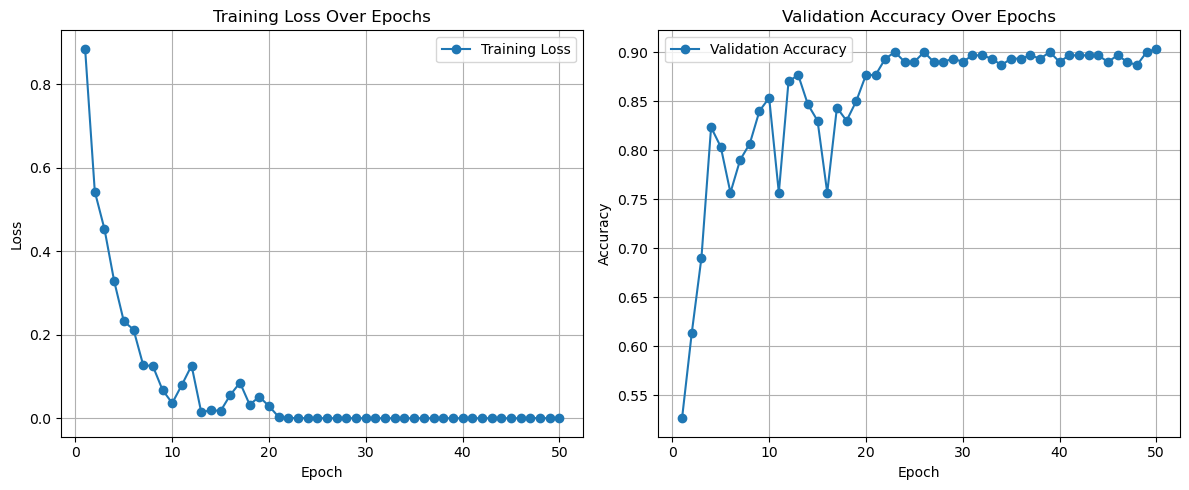


Model without Dropout training complete.
Final validation accuracy: 0.9033


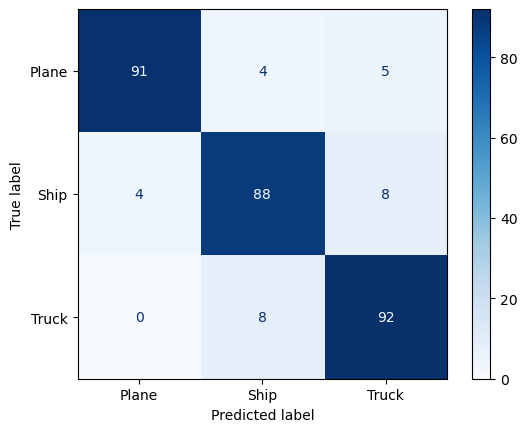

In [5]:
from src.vgg11bn import VGG11BN
from src.train import train_model, evaluate_model, plot_confusion_matrix, set_seed
from src.utils import ImageDataset
import torch.optim as optim
import torch.nn as nn
import torch
import torch.backends.cudnn as cudnn
from torch.optim.lr_scheduler import StepLR

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=50
)

print("\nModel without Dropout training complete.")

torch.save(trained_model.state_dict(), 'model_without_dropout.pth')

# evaluation
val_loss, val_acc = evaluate_model(trained_model, dataloaders['val'], criterion, device)
print(f"Final validation accuracy: {val_acc:.4f}")

# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])


Training without Dropout resulted in perfect memorization of the training set (100\% accuracy, 0.0 loss), but validation loss remained around 0.7. While validation accuracy peaked at 90.33\%, it later dropped to 88.33\%, indicating that the model overfit the training data. This highlights the need for regularization in high-capacity models like VGG11, especially when the dataset is limited.


### ✅ Where does Dropout go?

The VGG-11 classifier looks like this (after the convolutional blocks):

```text
Linear(512 * 7 * 7 → 4096)
ReLU
Dropout(0.5)

Linear(4096 → 4096)
ReLU
Dropout(0.5)

Linear(4096 → num_classes)
```

C:\\Users\\tihas\\OneDrive - UiT Office 365\\A_UIT\\FYS-3033\\HOME_EXAM\\FYS3033DL

## Problem 2c

Modify the network from Problem 2a to include Dropout with a dropout rate of 0.5 after each of the two layers that contain 4096 filters. **Discuss the results.**

Epoch 1/50
----------
train Loss: 0.8706 Acc: 0.6058
val Loss: 1.0206 Acc: 0.4800

Epoch 2/50
----------
train Loss: 0.6479 Acc: 0.7417
val Loss: 1.0411 Acc: 0.5333

Epoch 3/50
----------
train Loss: 0.4736 Acc: 0.8167
val Loss: 0.5881 Acc: 0.7500

Epoch 4/50
----------
train Loss: 0.3421 Acc: 0.8833
val Loss: 0.6373 Acc: 0.7600

Epoch 5/50
----------
train Loss: 0.2237 Acc: 0.9067
val Loss: 0.5836 Acc: 0.7633

Epoch 6/50
----------
train Loss: 0.1616 Acc: 0.9500
val Loss: 0.5260 Acc: 0.8500

Epoch 7/50
----------
train Loss: 0.2036 Acc: 0.9250
val Loss: 0.5845 Acc: 0.8133

Epoch 8/50
----------
train Loss: 0.0960 Acc: 0.9642
val Loss: 0.4723 Acc: 0.8733

Epoch 9/50
----------
train Loss: 0.1225 Acc: 0.9483
val Loss: 1.2007 Acc: 0.7633

Epoch 10/50
----------
train Loss: 0.0520 Acc: 0.9808
val Loss: 0.6265 Acc: 0.8333

Epoch 11/50
----------
train Loss: 0.0335 Acc: 0.9900
val Loss: 0.9380 Acc: 0.7800

Epoch 12/50
----------
train Loss: 0.0761 Acc: 0.9733
val Loss: 0.8545 Acc: 0.8000

E

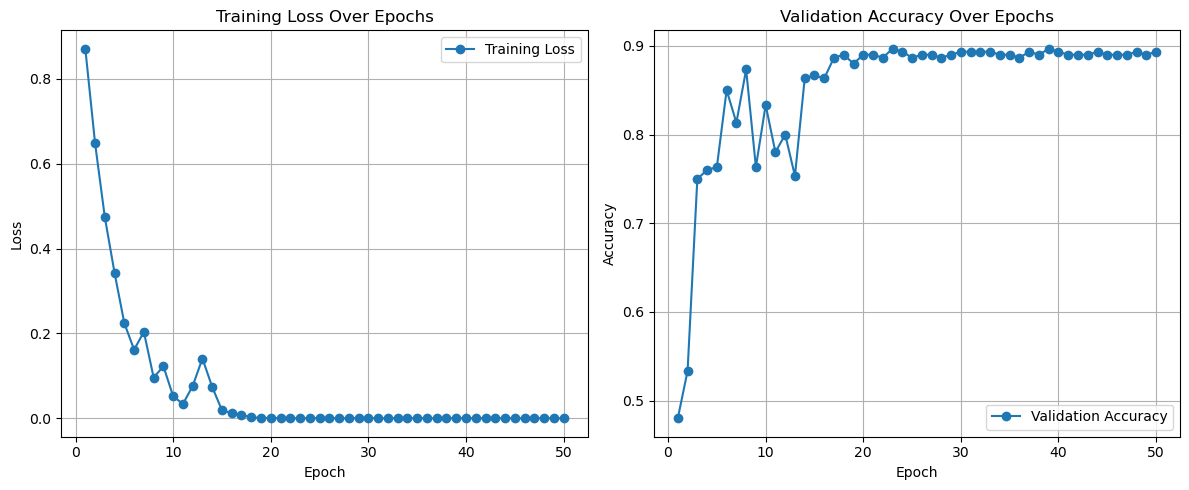


Model with Dropout training complete.
Final validation accuracy: 0.8933


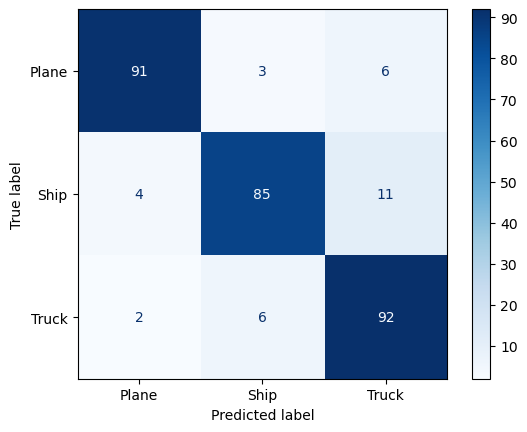

In [6]:
# Problem 2c: Train a VGG11BN model with dropout

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True

# ✅ Use a new model name for clarity
model2c = VGG11BN(num_classes=3, dropout=True).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2c.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model2c = train_model(
    model2c,
    dataloaders,
    criterion,
    optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=50
)

print("\nModel with Dropout training complete.")

torch.save(trained_model2c.state_dict(), 'model_with_dropout.pth')

# evaluation
val_loss, val_acc = evaluate_model(trained_model2c, dataloaders['val'], criterion, device)
print(f"Final validation accuracy: {val_acc:.4f}")

# Plot confusion matrix
plot_confusion_matrix(trained_model2c, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])


## Regularization Experiments: Dropout vs No Dropout

We trained the VGG11BN model both with and without Dropout using a batch size of 32 to evaluate the effect of Dropout regularization on a relatively small dataset.

- **Without Dropout**, the model achieved perfect training accuracy and a validation accuracy of **90.33%**.
- **With Dropout** (p=0.5 after the fully connected layers), the final validation accuracy was **89.33%**, with a slightly lower best accuracy of **89.67%**.
- In both cases, the training accuracy reached 100%, indicating the model could easily memorize the dataset.
- Interestingly, **validation loss remained around 0.60** in both setups, suggesting the model still made confident predictions, even when incorrect.

Dropout did not significantly improve validation performance in this case, possibly because the model was already regularized enough by the small batch size (32) and the relatively limited dataset. However, Dropout did help stabilize training and may prove more beneficial with noisier or more diverse data.

> **Note:** Surprisingly, the model trained with Dropout completed its training run in roughly half the time compared to the non-Dropout version. This makes sense, as Dropout disables a portion of neurons during training (50% in this case), effectively reducing the number of computations in the large fully connected layers — especially impactful in architectures like VGG11.


## Problem 2d

Leverage the Dropout mechanism in your trained network to create uncertainty estimates for each of the labeled images in the new dataset.

For a single sample, perform 10 forward passes with Dropout applied and calculate the mean softmax output across the 10 predictions. Then, calculate the entropy of the mean softmax output $\hat{y}$ as:

$$
H(\hat{y}) = -\sum_{i=1}^{N_c} \hat{y}_i \log(\hat{y}_i),
$$

where $N_c$ is the number of classes in your model. Explain why the entropy of the softmax output can be interpreted as a measure of uncertainty. 

Additionally, make a histogram plotting the entropy for the known classes and the new (unwanted) class, calculate the mean of each distribution, and mark them on the histogram. Discuss your observations.

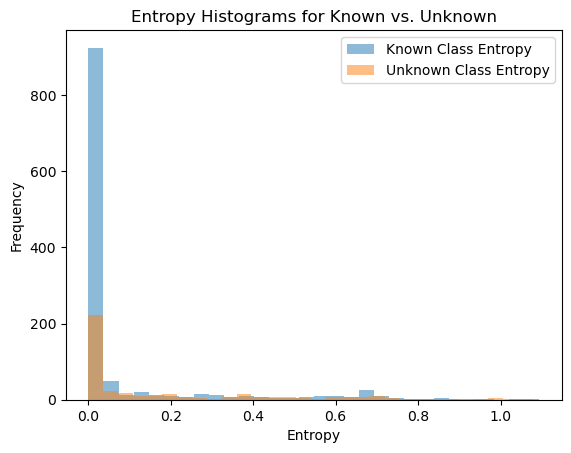

 Entropy histograms for known and unknown classes plotted successfully.


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Dataset
from src.utils import compute_entropy, plot_entropy_hist

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load data with real known/unknown labels ---
eval_data = np.load('data/problem2/new_evaluation_data_with_labels.npz')
eval_images = eval_data['a']          # shape: (N, 96, 96, 3)
eval_labels = eval_data['b']          # shape: (N,)

# Split data into known and unknown using labels
known_images = eval_images[eval_labels != 3]
unknown_images = eval_images[eval_labels == 3]

# --- Minimal PyTorch Dataset for unlabelled image data ---
class ImageDataset(Dataset):
    def __init__(self, images):
        # Normalize and transpose images (HWC → CHW)
        self.images = images.astype(np.float32) / 255.0
        self.images = self.images.transpose(0, 1, 2, 3)  # shape: (N, 3, 96, 96)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return torch.tensor(self.images[idx])  # shape: (3, 96, 96)

# --- DataLoaders ---
known_loader = DataLoader(ImageDataset(known_images), batch_size=32, shuffle=False)
unknown_loader = DataLoader(ImageDataset(unknown_images), batch_size=32, shuffle=False)

# --- MC Dropout Prediction ---
def mc_dropout_prediction(model, x_batch, mc_passes=10):
    model.train()  # keep dropout active

    probs_list = []
    with torch.no_grad():
        for _ in range(mc_passes):
            out = model(x_batch.to(device))
            sm = F.softmax(out, dim=1)
            probs_list.append(sm)
    probs_mc = torch.stack(probs_list, dim=0)       # (mc_passes, batch_size, num_classes)
    mean_probs = torch.mean(probs_mc, dim=0)        # (batch_size, num_classes)
    return mean_probs

# --- Uncertainty Estimation ---
entropies_known = []
entropies_unknown = []

model = model.to(device)

# Known class predictions
for inputs in known_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)
    entropies_known.extend([compute_entropy(p.cpu().numpy()) for p in mean_probs])

# Unknown class predictions
for inputs in unknown_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)
    entropies_unknown.extend([compute_entropy(p.cpu().numpy()) for p in mean_probs])

# --- Plot entropy histograms ---
plot_entropy_hist(entropies_known, entropies_unknown)

print(" Entropy histograms for known and unknown classes plotted successfully.")


In [19]:
# Problem 2e: Threshold determination for filtering unwanted images
# TODO: Implement the logic to determine a threshold based on the entropy values
# and report the detection statistics for unwanted versus desired images.

def determine_threshold(entropy_values, true_labels):
    # Placeholder for threshold determination logic
    # 'true_labels' should indicate which samples belong to known vs unwanted classes
    pass

# Example usage (with placeholder variables):
# threshold, stats = determine_threshold(entropy_values, true_labels)
# print('Threshold:', threshold)
# print('Detection Stats:', stats)

## Problem 2e

Using the results from Problem 2d, determine a threshold to detect as many images of the unwanted class (birds) as possible, while keeping as many images of the desired classes (plane, ship, truck) as possible. 

Report the number of unwanted images detected and the number of desired images that are removed in the process.

In [8]:
import numpy as np

# Convert lists to numpy arrays
entropies_known = np.array(entropies_known)
entropies_unknown = np.array(entropies_unknown)

# Let's pick a threshold halfway between the means
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)
threshold = (mean_known + mean_unknown) / 2

print(f"Mean Entropy (Known):   {mean_known:.4f}")
print(f"Mean Entropy (Unknown): {mean_unknown:.4f}")
print(f"Selected Threshold:      {threshold:.4f}")

# Apply threshold
# True unknowns detected = entropy > threshold
unknown_detected = np.sum(entropies_unknown > threshold)
unknown_total = len(entropies_unknown)

# False positives = known mistakenly removed
known_wrongly_rejected = np.sum(entropies_known > threshold)
known_total = len(entropies_known)

# Report
print(f"\n Detected {unknown_detected} out of {unknown_total} unknown-class images.")
print(f" Mistakenly removed {known_wrongly_rejected} out of {known_total} known-class images.")

# Optional: Save threshold for 2f
entropy_threshold = threshold


Mean Entropy (Known):   0.0834
Mean Entropy (Unknown): 0.1765
Selected Threshold:      0.1300

 Detected 143 out of 413 unknown-class images.
 Mistakenly removed 188 out of 1187 known-class images.


In [11]:
# **Solution Code for Problem 2e**

import numpy as np

# Let entropies_known, entropies_unknown be from previous steps.
# We'll pick a threshold such that e.g., 95th percentile of known entropies.
threshold = np.percentile(entropies_known, 95)

print(f"Chosen entropy threshold: {threshold:.4f}")

# Classify known set:
known_predictions = [1 if e > threshold else 0 for e in entropies_known]
# 0 => predicted known, 1 => predicted unknown

# Classify unknown set:
unknown_predictions = [1 if e > threshold else 0 for e in entropies_unknown]

# How many unwanted class samples (truly unknown) were correctly detected?
correctly_detected_unknown = sum(unknown_predictions)  # 1 means flagged unknown

# How many wanted class samples (truly known) were mistakenly removed?
# i.e., how many known samples got predicted unknown?
mistakenly_removed_known = sum(known_predictions)

print(f"Unwanted class samples correctly detected: {correctly_detected_unknown}")
print(f"Wanted class samples mistakenly removed: {mistakenly_removed_known}")


Chosen entropy threshold: 0.6473
Unwanted class samples correctly detected: 39
Wanted class samples mistakenly removed: 60


## Problem 2f (Bonus)

Pass the unlabeled part of the dataset through your trained model and predict known and unknown classes based on the threshold from Problem 2e. 

Store the predictions as a binary vector in a NumPy array and save it using `numpy.save` with the `.npz` extension. 

Remember not to shuffle the data when making your predictions.

In [12]:
# **Solution Code for Problem 2f**

# Suppose the unlabeled images have been loaded as:
unlabeled_data = np.load('data/problem2/new_evaluation_data_without_labels.npz')
unlabeled_images = unlabeled_data['a']

# unlabeled_images = np.random.randint(0, 255, (10, 96, 96, 3), dtype=np.uint8)  # dummy data
unlabeled_dataset = ImageDataset(unlabeled_images)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=32, shuffle=False)
model2c = VGG11BN(num_classes=3, dropout=True)

model.train() # ensure dropout is enabled

binary_predictions = []

for inputs in unlabeled_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)  # from above function
    # compute entropy
    for mp in mean_probs:
        ent = compute_entropy(mp)
        pred = 1 if ent > threshold else 0  # 1 => unknown, 0 => known
        binary_predictions.append(pred)

binary_predictions = np.array(binary_predictions)

# Save as .npz (not shuffling, preserving order)
np.savez('unlabeled_predictions2.npz', predictions=binary_predictions)

print("Saved binary predictions to 'unlabeled_predictions2.npz'.")


def plot_unlabeled_predictions(images, predictions, num_images=16):
    """
    Plot a subset of unlabeled images with their binary predictions.

    Parameters:
        images (numpy.ndarray): Array of unlabeled images.
        predictions (numpy.ndarray): Array of binary predictions (0 or 1).
        num_images (int): Number of images to display (default: 16).
    """
    # Select a subset of images and predictions
    indices = np.random.choice(len(images), num_images, replace=False)
    selected_images = images[indices]
    selected_predictions = predictions[indices]

    # Plot the images with their predictions
    plt.figure(figsize=(12, 8))
    import matplotlib.pyplot as plt
import numpy as np

def plot_unlabeled_predictions(images, predictions, num_images=16):
    """
    Plot a subset of unlabeled images with their binary predictions.

    Parameters:
        images (numpy.ndarray): Array of unlabeled images.
        predictions (numpy.ndarray): Array of binary predictions (0 or 1).
        num_images (int): Number of images to display (default: 16).
    """
    # Select a subset of images and predictions
    indices = np.random.choice(len(images), num_images, replace=False)
    selected_images = images[indices]
    selected_predictions = predictions[indices]

    # Plot the images with their predictions
    plt.figure(figsize=(12, 8))
    for i, (img, pred) in enumerate(zip(selected_images, selected_predictions)):
        ax = plt.subplot(4, 4, i + 1)  # Create a 4x4 grid
        ax.imshow(np.transpose(img, (1, 2, 0)))  # Convert channel-first to channel-last
        ax.axis('off')
        ax.set_title(f"Pred: {'Unwanted' if pred == 1 else 'Known'}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Load the saved binary predictions
binary_predictions = np.load('binary_predictions.npz.npy')

# Plot the predictions
plot_unlabeled_predictions(unlabeled_images, binary_predictions, num_images=16)


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [23]:
# --- Load unlabeled images ---
unlabeled_data = np.load('data/problem2/new_evaluation_data_without_labels.npz')
unlabeled_images = unlabeled_data['a']  # shape: (N, 96, 96, 3)

# --- Prepare dataset and loader ---
unlabeled_dataset = ImageDataset(unlabeled_images)  # should handle normalization & transpose
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=32, shuffle=False)

# --- Load model with Dropout enabled ---
model = VGG11BN(num_classes=3, dropout=True)
# model.load_state_dict(torch.load("vgg11_best.pth"))  # if you saved it earlier
model = model.to(device)
model.train()  # dropout ON

# --- Inference with MC Dropout ---
binary_predictions = []

for inputs in unlabeled_loader:
    inputs = inputs.to(device)
    mean_probs = mc_dropout_prediction(model, inputs, mc_passes=10)  # (batch_size, num_classes)
    entropies = [compute_entropy(p.cpu().numpy()) for p in mean_probs]
    preds = [1 if ent > threshold else 0 for ent in entropies]  # 1: unknown, 0: known
    binary_predictions.extend(preds)

binary_predictions = np.array(binary_predictions)

# --- Save predictions ---
np.savez('unlabeled_predictions2.npz', predictions=binary_predictions)

print("✅ Saved binary predictions to 'unlabeled_predictions.npz'.")


✅ Saved binary predictions to 'unlabeled_predictions.npz'.


In [9]:
def plot_unlabeled_predictions(images, predictions, num_images=16):
    """
    Plot a subset of unlabeled images with their binary predictions.

    Parameters:
        images (numpy.ndarray): Array of unlabeled images.
        predictions (numpy.ndarray): Array of binary predictions (0 or 1).
        num_images (int): Number of images to display (default: 16).
    """
    # Select a subset of images and predictions
    indices = np.random.choice(len(images), num_images, replace=False)
    selected_images = images[indices]
    selected_predictions = predictions[indices]

    # Plot the images with their predictions
    plt.figure(figsize=(12, 8))
    for i, (img, pred) in enumerate(zip(selected_images, selected_predictions)):
        ax = plt.subplot(4, 4, i + 1)  # Create a 4x4 grid
        ax.imshow(np.transpose(img, (1, 2, 0)))  # Convert channel-first to channel-last
        ax.axis('off')
        ax.set_title(f"Pred: {'Unwanted' if pred == 1 else 'Known'}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Load the saved binary predictions
binary_predictions = np.load('unlabeled_predictions2.npz')

# Plot the predictions
plot_unlabeled_predictions(unlabeled_images, binary_predictions, num_images=16)

NameError: name 'unlabeled_images' is not defined

# Problem 3: Traffic Sign Classification and Model Explanation

In this problem, you will train an image classifier on the provided traffic sign dataset and explore approaches to explain the model's predictions and detect potential backdoors.

## Problem 3a

Explain one approach that can be used to interpret or explain a specific prediction of a deep learning model, and one that can be used to interpret the model as a whole.

In [ ]:
# Problem 3a: Explanation of model interpretation methods
# TODO: Provide your explanation on model interpretation techniques here.
def explain_interpretation_methods():
    # Placeholder for explanation
    pass

explain_interpretation_methods()

## Problem 3b

Train a ResNet-18 to classify the traffic sign data. You are allowed to use frameworks like Torchvision (without pretrained weights).

Describe the network, your implementation, and report the obtained accuracy for the training and validation sets. Use the data from the `train` folder, splitting it into an 80%/20% train/validation set while preserving the class distribution.

In [ ]:
# Problem 3b: Training ResNet-18 for traffic sign classification
# TODO: Implement the ResNet-18 model training and evaluation.
# Include code for data loading, model definition, training loop, and accuracy reporting.

def train_resnet18():
    # Placeholder for data loading, model definition, training, and evaluation
    pass

train_resnet18()

## Problem 3c

Quantitatively and qualitatively inspect the results on the provided test images (from the `test` folder) and compare these results to those obtained on the validation set. Discuss your observations.

In [ ]:
# Problem 3c: Analysis of test set results
# TODO: Write code to evaluate the model on the test set and compare with validation results.
# Include visualizations and performance metrics to support your discussion.

def analyze_test_results():
    # Placeholder for evaluation and analysis
    pass

analyze_test_results()

## Problem 3d

For the class where the model fails on the test set, produce Class Saliency Maps for the training images as described in Section 3.1 of the references. Provide the saliency maps for 10 training images and comment on the observed results.

In [ ]:
# Problem 3d: Generate Class Saliency Maps
# TODO: Implement the computation of saliency maps for 10 training images
# and include code to display and comment on the results.

def generate_saliency_maps():
    # Placeholder for saliency map generation
    pass

generate_saliency_maps()

## Problem 3e

Perform an Occlusion Analysis on the same training images by occluding a $10\times10$ region and monitoring the classifier output. 

Provide illustrations similar to Figure 7(e) from the references and discuss your observations.

In [ ]:
# Problem 3e: Occlusion Analysis implementation
# TODO: Implement occlusion analysis by sliding a 10x10 window over the images,
# computing the change in classifier output, and visualizing the results.

def occlusion_analysis():
    # Placeholder for occlusion analysis code
    pass

occlusion_analysis()

## Problem 3f

Based on your observations from the previous parts, propose an approach to modify the training data to remove the backdoor present in the dataset.

In [ ]:
# Problem 3f: Proposal for modifying training data to remove the backdoor
# TODO: Provide your proposed method for modifying the training data
# to mitigate the backdoor effect.

def propose_data_modification():
    # Placeholder for your proposal
    pass

propose_data_modification()

## Problem 3g

Retrain your classifier on the modified data and report the new results on the test images. Discuss your outcomes.

In [ ]:
# Problem 3g: Retraining the classifier on modified data
# TODO: Implement retraining of the classifier on the modified dataset
# and evaluate the performance on the test set.

def retrain_classifier():
    # Placeholder for retraining and evaluation code
    pass

retrain_classifier()

## Problem 3h

Provide the saliency maps and the occlusion analysis maps for the new model (from Problem 3g) for the same images used in Problems 3d and 3e. Discuss your observations.

In [ ]:
# Problem 3h: Saliency and occlusion analysis for the new model
# TODO: Generate and display saliency maps and occlusion analysis for the new model
# and provide commentary on the results.

def new_model_analysis():
    # Placeholder for generating new analysis plots
    pass

new_model_analysis()

## Final Notes

Make sure to include all your code and explanations in the designated cells. 
Review your notebook to ensure that it follows the assignment instructions and is well-commented.
Remember to save your work and submit both your report and code as instructed.